<a href="https://colab.research.google.com/github/Priyanshi-6014/handling_imbalanced_data_smote/blob/main/SMOTE_imbalanced_classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns

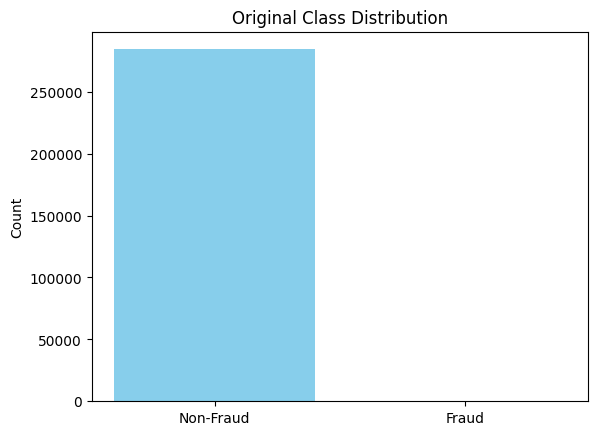

In [14]:
data = pd.read_csv("sample_data/creditcard.csv")
data = data.dropna(subset=["Class"])

X = data.drop("Class", axis=1)
y = data["Class"]

X = X.fillna(X.median())

plt.bar(y.value_counts().index, y.value_counts().values, color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Original Class Distribution")
plt.show()

In [ ]:

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

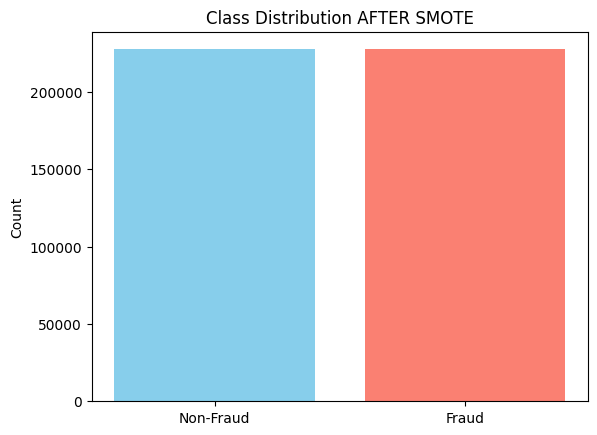

In [ ]:
#Apply SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values,
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_sm, y_train_sm)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy AFTER SMOTE: 97.75 %

Classification Report AFTER SMOTE:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



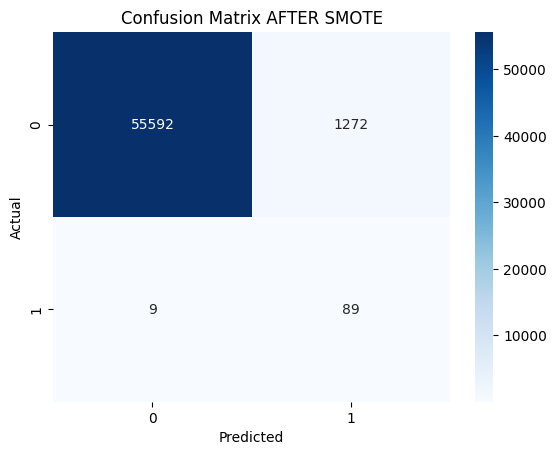

In [ ]:
model.fit(X_train_sm, y_train_sm)

y_pred_sm = model.predict(X_test)

print("Accuracy AFTER SMOTE:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
print("Classification Report AFTER SMOTE:\n", classification_report(y_test, y_pred_sm))

sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

After applying SMOTE the model becomes better at detecting the minority class but at the cost of increased false positives highlighting the trade-off between recall and precision in imbalanced datasets.
